In [126]:
import pandas as pd
import numpy as np
import re
import os
from typing import List, Dict, Union, Tuple
from tqdm import tqdm



from sklearn.metrics import (
    f1_score, adjusted_rand_score, normalized_mutual_info_score
)

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()


True

### 클러스터 결과 load

In [13]:
# 1. 클러스터의 argmax값을 붙인 csv파일을 로드
df = pd.read_csv('/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/cluster_20ng.csv')
df.head()

,text,label_id,label_name,cleaned_text,cluster_label
0,i am sure some bashers of pens fans are pretty...,10,rec.sport.hockey,sure basher pen fan confused lack kind post re...,10
1,my brother is in the market for a high perform...,3,comp.sys.ibm.pc.hardware,brother market high performance video card loc...,3
2,the student of regional killings alias davidia...,17,talk.politics.mideast,student regional killing alias davidian davidi...,17
3,in article wayne smith writes think it s the s...,3,comp.sys.ibm.pc.hardware,scsi card dma transfer disk scsi card transfer...,3
4,1 i have an old jasmine drive which i cannot u...,4,comp.sys.mac.hardware,old jasmine drive new understanding driver mod...,3


In [22]:
# text
def prepare_texts(df, col="cleaned_text"):
    # 각 문장을 토큰 리스트로 변환
    texts = []
    for s in df[col].astype(str):
        tokens = re.findall(r"[A-Za-z]+", s.lower())  # 알파벳만 추출, 소문자화
        texts.append(tokens)
    return texts

In [16]:
# topic
def load_topics_from_file(path: str, topn: int = 10):
    """
    path: topic_words.txt 파일 경로
    반환: topics = [["moral","argument","homosexual",...], ["image","jpeg",...], ...]
    """
    topics = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            # "Topic 0: moral, argument, homosexual, ..." 형태 가정
            line = line.strip()
            if not line:
                continue
            # "Topic", "번호:" 부분 제거 → 단어만 추출
            words = re.split(r"[:,\s]+", line)[2:]
            words = [w for w in words if w]
            topics.append(words[:topn])
    return topics

def prepare_texts(df, col="cleaned_text"):
    return [re.findall(r"[A-Za-z]+", str(s).lower()) for s in df[col].astype(str)]

def build_dict_corpus(texts):
    id2word = Dictionary(texts)
    corpus = [id2word.doc2bow(toks) for toks in texts]
    return id2word, corpus

topics = load_topics_from_file(
    "/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/topic_words.txt",
    topn=10
)
texts_tokenized = prepare_texts(df, "cleaned_text")
id2word, corpus = build_dict_corpus(texts_tokenized)

### 클러스터 metric 계산

In [19]:
from typing import List, Dict
import re
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from sklearn.metrics import f1_score, adjusted_rand_score, normalized_mutual_info_score

def compute_cv(topics: List[List[str]], tokenized_texts: List[List[str]], topn: int = 10) -> float:
    id2word = Dictionary(tokenized_texts)
    cm = CoherenceModel(
        topics=[t[:topn] for t in topics],
        texts=tokenized_texts,
        dictionary=id2word,
        coherence="c_v"
    )
    return cm.get_coherence()

def compute_td(topics: List[List[str]], topn: int = 10) -> float:
    all_words = []
    for t in topics:
        all_words.extend(t[:topn])
    return len(set(all_words)) / len(all_words) if all_words else 0.0

def _tokenize_docs(raw_texts: List[str]) -> List[List[str]]:
    return [re.findall(r"[A-Za-z]+", str(s).lower()) for s in raw_texts]

def evaluate_topics_and_clusters(
    labels_true: List[int],
    labels_pred_aligned: List[int],  # 이미 헝가리안 매칭된 상태
    topics: List[List[str]] = None,
    texts: List[str] = None,         # 원문 문자열 리스트 (토큰화는 내부에서)
    topn: int = 10
) -> Dict:
    # External metrics
    p1  = f1_score(labels_true, labels_pred_aligned, average="macro")  # P1 ≈ macro-F1
    ari = adjusted_rand_score(labels_true, labels_pred_aligned)
    nmi = normalized_mutual_info_score(labels_true, labels_pred_aligned)

    # Topic metrics
    cv_score, td = None, None
    if topics is not None and texts is not None:
        tokenized = _tokenize_docs(texts)
        cv_score  = compute_cv(topics, tokenized, topn=topn)
        td        = compute_td(topics, topn=topn)

    return {
        "p1_macro_f1": p1,
        "ari": ari,
        "nmi": nmi,
        "topic_coherence_cv": cv_score,
        "topic_diversity": td,
    }


In [21]:
labels_true = df['label_id']                  # 길이 N
labels_pred  = df['cluster_label']                 # 길이 N (이미 헝가리안 매칭 완료)

res = evaluate_topics_and_clusters(
    labels_true=labels_true,
    labels_pred_aligned=labels_pred,
    topics=topics,                             # 없으면 None 가능
    texts=df["cleaned_text"].tolist(),         # topics 주는 경우 함께 전달
    topn=10
)

print(res)

{'p1_macro_f1': 0.5813511759327064, 'ari': 0.4217166957613969, 'nmi': 0.5681847387504138, 'topic_coherence_cv': 0.7217309169026398, 'topic_diversity': 0.88}


### retopic 대상 선정

불러오기

In [23]:
# soft result 불러오기
def load_soft_results(path: str):
    data = np.load(path, allow_pickle=True)
    P = data["P"]
    C = data["C"]
    y_pred_hard = data["y_pred_hard"]
    y_pred_aligned = data["y_pred_aligned"]
    mapping_arr = data["mapping"]
    mapping = {int(k): int(v) for k, v in mapping_arr}
    return P, C, mapping, y_pred_hard, y_pred_aligned

P_loaded, C_loaded, mapping_loaded, y_hard_loaded, y_aligned_loaded = load_soft_results("/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/soft_results.npz")

In [41]:
embeddings = np.load('/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/embeddings.npz')

정규화

In [24]:
def _row_normalize(P: np.ndarray) -> np.ndarray:
    """행 합이 1이 아니면 안전하게 정규화."""
    P = np.asarray(P, dtype=np.float64)
    s = P.sum(axis=1, keepdims=True)
    Pn = np.divide(P, np.where(s > 0, s, 1.0), out=np.zeros_like(P), where=s > 0)
    return np.clip(Pn, 0.0, 1.0)

기준 1) 낮은 신뢰도 / 작은 마진
- conf_i = max_j p_ij
- margin_i = p_(1) - p_(2)  (상위 두 확률 차이)
- 규칙: conf_i < τ_conf  (또는/그리고)  margin_i < τ_margin

In [25]:
def select_by_confidence_margin(
    P: np.ndarray,
    tau_conf: float = 0.55,
    tau_margin: float = 0.20,
    logic: str = "or",  # "or" 또는 "and"
) -> list[int]:
    
    P = _row_normalize(P)

    # 각 행의 top-1, top-2 확률 구하기
    top2_idx = np.argpartition(-P, 2, axis=1)[:, :2]
    top2_vals = np.take_along_axis(P, top2_idx, axis=1)
    p1 = top2_vals.max(axis=1)
    p2 = top2_vals.sum(axis=1) - p1

    conf = p1
    margin = p1 - p2

    if logic == "and":
        mask = (conf < tau_conf) & (margin < tau_margin)
    else:  # "or"
        mask = (conf < tau_conf) | (margin < tau_margin)

    return np.where(mask)[0].tolist()

In [30]:
# 1) 낮은 신뢰도 / 작은 마진
idx_confmargin = select_by_confidence_margin(
    P_loaded, tau_conf=0.55, tau_margin=0.20, logic="or"
)

In [47]:
print("Confidence/Margin 대상:",
      len(idx_confmargin),
      f"({len(idx_confmargin) / len(df):.2%})")

Confidence/Margin 대상: 7269 (39.86%)


In [50]:
df_remain = df.drop(index=idx_confmargin).reset_index(drop=True)
print(f"원래 크기: {len(df)}, 제거 후 크기: {len(df_remain)}")

labels_true_remain = df_remain["label_id"].to_numpy()
labels_pred_remain = df_remain["cluster_label"].to_numpy()

# 4) metric 계산
res = evaluate_topics_and_clusters(
    labels_true=labels_true_remain,
    labels_pred_aligned=labels_pred_remain,
    topics=topics,                     # 토픽 지표를 보고 싶다면 그대로 넣기
    texts=df_remain["cleaned_text"].tolist(),
    topn=10
)

print(res)

원래 크기: 18235, 제거 후 크기: 10966
{'p1_macro_f1': 0.6708419831822843, 'ari': 0.7020695947615485, 'nmi': 0.7840742501160964, 'topic_coherence_cv': 0.7071543893482073, 'topic_diversity': 0.88}


기준 2) 높은 엔트로피
- H_i = -∑_j p_ij log(p_ij + 1e-12)
- 규칙: H_i > τ_H  또는 상위 q% 선택

In [53]:
def select_by_entropy(
    P: np.ndarray,
    top_frac: float = 0.10,  # 상위 q% 큰 엔트로피 선택
    tau_H: float | None = None,
) -> list[int]:

    P = _row_normalize(P)
    H = -(P * np.log(P + 1e-12)).sum(axis=1)

    if tau_H is not None:
        mask = H > tau_H
    else:
        k = max(1, int(np.ceil(len(H) * top_frac)))
        cutoff = np.partition(H, -k)[-k]  # 큰 값 상위 k번째 기준
        mask = H >= cutoff

    return np.where(mask)[0].tolist()

In [63]:
# 2) 높은 엔트로피
idx_entropy = select_by_entropy(
    P_loaded, top_frac=0.35  # 상위 10% 엔트로피
)

In [64]:
print("Entropy 대상:",
      len(idx_entropy),
      f"({len(idx_entropy) / len(df):.2%})")

Entropy 대상: 6383 (35.00%)


In [65]:
df_remain = df.drop(index=idx_entropy).reset_index(drop=True)
print(f"원래 크기: {len(df)}, 제거 후 크기: {len(df_remain)}")

labels_true_remain = df_remain["label_id"].to_numpy()
labels_pred_remain = df_remain["cluster_label"].to_numpy()

# 4) metric 계산
res = evaluate_topics_and_clusters(
    labels_true=labels_true_remain,
    labels_pred_aligned=labels_pred_remain,
    topics=topics,                     # 토픽 지표를 보고 싶다면 그대로 넣기
    texts=df_remain["cleaned_text"].tolist(),
    topn=10
)

print(res)

원래 크기: 18235, 제거 후 크기: 11852
{'p1_macro_f1': 0.6563411741825631, 'ari': 0.6431227470754693, 'nmi': 0.7518004258103165, 'topic_coherence_cv': 0.7130402323776689, 'topic_diversity': 0.88}


기준 3) 중심으로부터의 이상치(클러스터별 z-score)
- j* = argmax_j p_ij
- d_i = ||x_i - c_{j*}||_2
- z_i = (d_i - mean_j) / std_j   (클러스터 j 내에서)
- 규칙: z_i > τ_z  (또는 클러스터별 z 상위 q%)

In [66]:
def select_by_centroid_outlier(
    X: np.ndarray,   # (N, D) 임베딩
    C: np.ndarray,   # (K, D) 중심
    P: np.ndarray,   # (N, K) 소프트 멤버십
    z_thresh: float = 2.0,
    per_cluster_top_frac: float | None = None,  # 각 클러스터별 상위 q%로 제한(옵션)
) -> list[int]:

    P = _row_normalize(P)
    hard = P.argmax(axis=1)                 # j*
    dists = np.linalg.norm(X - C[hard], axis=1)

    # 클러스터별 z-score 계산
    z = np.zeros_like(dists)
    for j in range(C.shape[0]):
        idx_j = np.where(hard == j)[0]
        if idx_j.size == 0:
            continue
        dj = dists[idx_j]
        mu, sigma = dj.mean(), dj.std(ddof=0)
        if sigma <= 1e-12:
            z[idx_j] = 0.0
        else:
            z[idx_j] = (dj - mu) / sigma

    if per_cluster_top_frac is None:
        return np.where(z > z_thresh)[0].tolist()
    else:
        # 각 클러스터에서 z 큰 상위 q% 선택 (과대표집 방지)
        selected = []
        for j in range(C.shape[0]):
            idx_j = np.where(hard == j)[0]
            if idx_j.size == 0:
                continue
            k = max(1, int(np.ceil(idx_j.size * per_cluster_top_frac)))
            topk_local = idx_j[np.argsort(z[idx_j])[-k:]]
            selected.append(topk_local)
        return np.sort(np.concatenate(selected)).tolist()

In [67]:
X = embeddings["X"].astype(np.float32)  

In [68]:
# 3) 중심거리 아웃라이어
idx_outlier = select_by_centroid_outlier(
    X,               # (N, D) 임베딩 행렬 (별도 보관한 것 사용)
    C_loaded,        # (K, D) 정렬된 중심
    P_loaded,        # (N, K) 정렬된 소프트 멤버십
    z_thresh=2.5,    # z-score 기준
    per_cluster_top_frac=0.35  # 각 클러스터별 상위 10% 선택
)

In [69]:
print("Outlier 대상:",
      len(idx_outlier),
      f"({len(idx_outlier) / len(df):.2%})")

Outlier 대상: 6392 (35.05%)


In [70]:
df_remain = df.drop(index=idx_outlier).reset_index(drop=True)
print(f"원래 크기: {len(df)}, 제거 후 크기: {len(df_remain)}")

labels_true_remain = df_remain["label_id"].to_numpy()
labels_pred_remain = df_remain["cluster_label"].to_numpy()

# 4) metric 계산
res = evaluate_topics_and_clusters(
    labels_true=labels_true_remain,
    labels_pred_aligned=labels_pred_remain,
    topics=topics,                     # 토픽 지표를 보고 싶다면 그대로 넣기
    texts=df_remain["cleaned_text"].tolist(),
    topn=10
)

print(res)

원래 크기: 18235, 제거 후 크기: 11843
{'p1_macro_f1': 0.6110490830039429, 'ari': 0.46351934588172433, 'nmi': 0.6122998068182741, 'topic_coherence_cv': 0.7189884887204425, 'topic_diversity': 0.88}


### retopic 프롬프트 선정

In [87]:
# way 1: 프롬프트와 topic words를 주고 할당하기
def build_prompt_with_topics(topics: list[list[str]], text: str) -> str:
    topic_descriptions = []
    for i, words in enumerate(topics):
        topic_descriptions.append(f"Topic {i}: {', '.join(words)}")
    topic_block = "\n".join(topic_descriptions)

    prompt = f"""
You are an expert annotator for topic modeling.

We have the following predefined topics, each represented by its top words:
{topic_block}

Task:
1. Read the document below.
2. Summarize it briefly.
3. Decide which topic ID best matches the document.

Document:
\"\"\"{text}\"\"\"

Choose the single most appropriate topic, even if the match is not perfect. 
Return only the topic ID as an integer.
"""
    return prompt

In [105]:
# way 2: 텍스트만 주고 topic을 단어로 받은 다음, 스냅핑해서 할당하기
def build_prompt_free_topic(text: str) -> str:
    
    prompt = f"""
You are an expert annotator for topic modeling.

Task:
1. Read the document below.
2. Think carefully about its main subject.
3. Propose a concise topic label (3 words).

Document:
\"\"\"{text}\"\"\"

Return only the topic label. Do not output any explanation.
""" 
    return prompt

### GPT Call
1번 방법이 가장 효과가 좋아보이니, 1번의 인덱스를 가지고 call

In [83]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

[1] top words 주고 라벨

In [116]:
import re
import pandas as pd

def _to_index_labels(df: pd.DataFrame, idx_list):
    """idx_list가 위치기반(0..N-1)인지 라벨기반인지 감지 후 '라벨'로 통일."""
    idx = df.index
    # 모든 값이 현재 df.index에 존재하면 라벨로 간주
    if all(i in idx for i in idx_list):
        return list(idx_list)  # 이미 라벨
    # 아니라면 '정수 위치'로 간주하고 라벨로 변환
    return idx.take(idx_list).tolist()

def _sanitize_free_label(s: str, max_words: int = 3) -> str:
    s = (s or "").strip()
    # 한 줄만 사용
    s = s.splitlines()[0]
    # 따옴표/마침표 등 가벼운 트리밍
    s = re.sub(r"[\"'`]+", "", s)
    # 토큰 기준 최대 max_words로 자르기
    toks = re.findall(r"[A-Za-z가-힣0-9\-]+", s)
    toks = toks[:max_words] if toks else []
    if not toks:
        return ""
    # 제목 형태로 살짝 정돈 (원하면 .lower() 유지 가능)
    return " ".join(toks).strip()

def gpt_label_subset(
    df: pd.DataFrame,
    idx_list: list[int],
    topics: list[list[str]] | None,
    mode: str = "predefined",        # "predefined" | "free"
    text_col: str = "text",
    model: str = "gpt-4o-mini",
    max_chars: int = 4000,
    column_name: str | None = None,
    temperature: float = 0.0,
) -> pd.DataFrame:
    assert text_col in df.columns, f"'{text_col}' 컬럼이 없습니다."
    if mode == "predefined":
        assert topics is not None and len(topics) > 0, "predefined 모드에는 topics가 필요합니다."
        K = len(topics)
        column_name = column_name or "gpt_topic_id"
    else:
        column_name = column_name or "gpt_topic_free"

    # 대상 인덱스를 '라벨 인덱스'로 표준화
    target_labels = _to_index_labels(df, idx_list)

    # 결과 컬럼을 '전체 인덱스에 맞춘 object/Int64 시리즈'로 초기화
    if mode == "predefined":
        if column_name not in df.columns or df[column_name].dtype != "Int64":
            df[column_name] = pd.Series(pd.NA, index=df.index, dtype="Int64")
    else:
        if column_name not in df.columns or df[column_name].dtype != "object":
            df[column_name] = pd.Series(None, index=df.index, dtype="object")

    # 진행
    for ix in target_labels:
        text = str(df.at[ix, text_col])
        if not text.strip():
            df.loc[ix, column_name] = (pd.NA if mode == "predefined" else None)
            continue

        text_trim = text[:max_chars]
        prompt = build_prompt_with_topics(topics, text_trim) if mode == "predefined" else build_prompt_free_topic(text_trim)

        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": "You are a helpful assistant."},
                    {"role": "user", "content": prompt},
                ],
                max_tokens=(8 if mode == "predefined" else 16),
                temperature=temperature,
            )
            out = (resp.choices[0].message.content or "").strip()

            if mode == "predefined":
                m = re.search(r"-?\d+", out)
                topic_id = int(m.group()) if m else -1
                if not (0 <= topic_id < K):
                    topic_id = -1
                df.loc[ix, column_name] = topic_id
            else:
                label = _sanitize_free_label(out, max_words=3)
                df.loc[ix, column_name] = (label if label else None)
                saved = df.at[ix, column_name]
                print(f"[saved] idx={ix} -> {saved!r}")     

        except Exception as e:
            df.loc[ix, column_name] = (pd.NA if mode == "predefined" else None)
            print(f"[warn] index {ix} GPT call failed: {e}")

    return df


In [ ]:
# 1) (선택) idx_confmargin 같은 대상 인덱스만 골라서
idx_target = idx_confmargin  # 또는 idx_entropy, idx_outlier 등

# 2-A) 미리 정의한 토픽 중 선택(정수 ID 반환)
df = gpt_label_subset(
    df=df,
    idx_list=idx_target,
    topics=topics,           # load_topics_from_file(...) 결과
    mode="predefined",
    text_col="text",
    model="gpt-4o-mini",
    column_name="gpt_topic_id",   # 새 컬럼명 (없으면 기본값)
)

df.loc[idx_target, ["text", "gpt_topic_id"]]  # 또는 "gpt_topic_free"


In [96]:
df["gpt_label"] = df.apply(
    lambda row: row["cluster_label"] if (pd.isna(row["gpt_topic_id"]) or row["gpt_topic_id"] == -1)
    else row["gpt_topic_id"],
    axis=1
)

In [113]:
labels_true_eval = df["label_id"].to_numpy()
labels_pred_eval = df["gpt_label"].astype(int).to_numpy()

# 3) 지표 계산
res = evaluate_topics_and_clusters(
    labels_true=labels_true_eval,
    labels_pred_aligned=labels_pred_eval,
    topics=topics,                                  # 토픽 지표 포함
    texts=df["cleaned_text"].tolist(),
    topn=10
)
print(res)

{'p1_macro_f1': 0.5846927354519187, 'ari': 0.40664676902111185, 'nmi': 0.57984063385804, 'topic_coherence_cv': 0.7217309169026398, 'topic_diversity': 0.88}


[2] 자유 라벨

In [ ]:
# 2-B) 자유 라벨 생성(짧은 문자열)
df = gpt_label_subset(
    df=df,
    idx_list=idx_target,
    topics=None,
    mode="free",
    text_col="text",
    model="gpt-4o-mini",
    column_name="gpt_topic_free",
)

# 확인

In [121]:
df.tail()

,text,label_id,label_name,cleaned_text,cluster_label,gpt_topic_id,gpt_label,gpt_topic_free
18230,dn from david nye dn a neurology dn consultati...,13,sci.med,neurology consultation cheap scan neurologist ...,13,<NA>,13,None
18231,in article engineer by day asleep by night wri...,12,sci.electronics,engineer day asleep night isolated ground rece...,12,<NA>,12,None
18232,i just installed a dx2 66 cpu in a clone mothe...,3,comp.sys.ibm.pc.hardware,cpu clone motherboard cpu cooler chip hour wei...,3,4,4,CPU Cooler Installation
18233,in article edward bolson writes wouldn t this ...,1,comp.graphics,wouldn hyper sphere space point specifie spher...,14,<NA>,14,None
18234,after a tip from gary crum i got on the phone ...,7,rec.autos,tip gary crum pontiac pontaic customer service...,7,<NA>,7,None


In [122]:
# gpt_topic_free gpt4 임베딩 뽑기
import tiktoken

enc = tiktoken.encoding_for_model("text-embedding-3-small")
MAX_TOKENS = 8192
def truncate_text(text: str, max_tokens: int = MAX_TOKENS) -> str:
    toks = enc.encode(text or "")
    if len(toks) > max_tokens:
        toks = toks[:max_tokens]
    return enc.decode(toks)

In [123]:
def get_embed_dim(model_name: str) -> int:
    name = model_name.lower()
    if "text-embedding-3-large" in name:
        return 3072
    # small/ada-002 등 기본 1536
    return 1536

In [127]:
def embed_texts_and_align_labels(
    texts: List[Union[str, List[str]]],   # string 또는 tokenized list
    labels: List[int],
    model: str = "text-embedding-3-small"
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, List[int]]]:
    """
    반환:
      X: (N, D)  - 입력 개수 그대로 유지(빈/실패는 0-벡터)
      mask_nonzero: (N,) - 0-벡터가 아닌 행(True)
      labels_clean: (M,) - mask_nonzero 적용
      texts_clean:  (M,) - mask_nonzero 적용
      logs: dict    - {'ok': [...], 'empty': [...], 'fail': [...], 'dim': D}
    """
    assert len(texts) == len(labels), f"len(texts)={len(texts)} vs len(labels)={len(labels)}"
    N = len(texts)
    D = get_embed_dim(model)

    X = np.zeros((N, D), dtype=np.float32)
    mask_nonzero = np.zeros(N, dtype=bool)

    ok_idx: List[int] = []
    empty_idx: List[int] = []
    fail_idx: List[int] = []

    print("[2] Call API for Embeddings...")
    for idx, raw in enumerate(tqdm(texts, desc="Embedding", total=N)):
        text = " ".join(map(str, raw)) if isinstance(raw, list) else str(raw)
        text = truncate_text(text.strip())
        if not text:
            empty_idx.append(idx)
            continue
        try:
            resp = client.embeddings.create(model=model, input=text)
            vec = np.asarray(resp.data[0].embedding, dtype=np.float32)

            # 차원 안전장치
            if vec.shape[0] != D:
                print(f"[warn] idx={idx} dim change: {vec.shape[0]} != {D}. Adjusting matrix.")
                newD = vec.shape[0]
                if newD > D:
                    pad = np.zeros((N, newD - D), dtype=np.float32)
                    X = np.hstack([X, pad])
                else:
                    X = X[:, :newD]
                D = newD

            X[idx] = vec
            mask_nonzero[idx] = True
            ok_idx.append(idx)
        except Exception as e:
            print(f"[warn] idx={idx} embedding failed: {e!r}")
            fail_idx.append(idx)

    # 요약 로그
    print("\n=== Embedding Summary ===")
    print(f"Total inputs   : {N}")
    print(f"OK             : {len(ok_idx)}")
    print(f"Empty texts    : {len(empty_idx)}")
    print(f"API failures   : {len(fail_idx)}")
    print(f"Kept (non-zero): {mask_nonzero.sum()} | Dropped: {(~mask_nonzero).sum()}")
    if empty_idx[:5]:
        print(f"First empty idx: {empty_idx[:5]}")
    if fail_idx[:5]:
        print(f"First fail idx : {fail_idx[:5]}")

    labels_arr = np.asarray(labels)
    texts_arr  = np.asarray(texts, dtype=object)
    labels_clean = labels_arr[mask_nonzero]
    texts_clean  = texts_arr[mask_nonzero]

    logs = {"ok": ok_idx, "empty": empty_idx, "fail": fail_idx, "dim": int(X.shape[1])}
    return X, mask_nonzero, labels_clean, texts_clean, logs

In [128]:
mask_has_free = df["gpt_topic_free"].notna() & (df["gpt_topic_free"].astype(str).str.strip() != "")
idx_free = df.index[mask_has_free]

texts_for_embed: List[str] = df.loc[idx_free, "gpt_topic_free"].astype(str).apply(truncate_text).tolist()
dummy_labels = [0] * len(texts_for_embed)

X_free, nz_mask, _, texts_clean, logs = embed_texts_and_align_labels(
    texts=texts_for_embed,
    labels=dummy_labels,
    model="text-embedding-3-small",
)

[2] Call API for Embeddings...


Embedding: 100%|██████████| 7269/7269 [39:51<00:00,  3.04it/s]  


=== Embedding Summary ===
Total inputs   : 7269
OK             : 7269
Empty texts    : 0
API failures   : 0
Kept (non-zero): 7269 | Dropped: 0


In [129]:
ok_local_idxs = np.array(logs["ok"], dtype=int)
ok_global_idxs = idx_free.to_numpy()[ok_local_idxs]  # df 기준 인덱스

In [130]:
# centroid 불러오기
def l2_normalize(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = np.linalg.norm(a, axis=1, keepdims=True)
    n = np.clip(n, eps, None)
    return a / n

In [131]:
D_cent = C_loaded.shape[1]
D_free = X_free.shape[1]
if D_cent != D_free:
    print(f"[warn] Centroid dim ({D_cent}) != Embedding dim ({D_free}). Adjusting...")
    if D_cent > D_free:
        # 임베딩에 0-padding
        pad = np.zeros((X_free.shape[0], D_cent - D_free), dtype=X_free.dtype)
        X_use = np.hstack([X_free, pad])
        C_use = C_loaded
    else:
        # 차원 자르기 (상위 D_cent로)
        X_use = X_free[:, :D_cent]
        C_use = C_loaded
else:
    X_use = X_free
    C_use = C_loaded

In [132]:
Xn = l2_normalize(X_use[nz_mask])   # (M, D)
Cn = l2_normalize(C_use)            # (K, D)
S = Xn @ Cn.T                       # (M, K) — 코사인 유사도

nearest_topic_local = np.argmax(S, axis=1)  # (M,)

In [133]:
# 매핑하기
def apply_label_mapping(labels_k: np.ndarray, mapping) -> np.ndarray:
    """mapping이 dict 또는 list/np.ndarray(길이=K)인 경우를 지원."""
    if mapping is None:
        return labels_k
    if isinstance(mapping, dict):
        return np.array([mapping.get(int(k), int(k)) for k in labels_k], dtype=int)
    elif isinstance(mapping, (list, np.ndarray)):
        mapping = np.asarray(mapping)
        assert mapping.shape[0] >= labels_k.max() + 1, "mapping size < max label"
        return mapping[labels_k]
    else:
        return labels_k

nearest_topic_aligned = apply_label_mapping(nearest_topic_local, mapping_loaded)

In [134]:
# 저장하기
df["gpt_free_label"] = df["cluster_label"].astype(int)

# gpt_topic_free 존재 + 임베딩 성공인 행만 갱신
df.loc[ok_global_idxs, "gpt_free_label"] = nearest_topic_aligned.astype(int)

# (선택) 디버그: 몇 개 확인
print("Assigned with GPT-free embeddings:", len(ok_global_idxs))
print(df.loc[ok_global_idxs, ["gpt_topic_free", "gpt_free_label"]].head())

Assigned with GPT-free embeddings: 7269
                   gpt_topic_free  gpt_free_label
5   Visual Perception Experiments               4
6           Tech Support Contacts              11
8       Bruins Goalie Performance              13
12           Ordo Templi Orientis               2
14   Aviation Learning Experience              19


In [140]:
labels_true_eval = df["label_id"].to_numpy()
labels_pred_eval = df["gpt_free_label"].astype(int).to_numpy()

# 3) 지표 계산
res = evaluate_topics_and_clusters(
    labels_true=labels_true_eval,
    labels_pred_aligned=labels_pred_eval,
    topics=topics,                                  # 토픽 지표 포함
    texts=df["cleaned_text"].tolist(),
    topn=10
)
print(res)

{'p1_macro_f1': 0.4495395078294343, 'ari': 0.3052794002266253, 'nmi': 0.462918933518427, 'topic_coherence_cv': 0.7217309169026398, 'topic_diversity': 0.88}


성능이 안좋을 리가 없어!!!

NPZ keys: ['P', 'C', 'y_pred_hard', 'y_pred_aligned', 'mapping']
C_loaded shape: (20, 1536)
[diag] centroid L2-norm -> min=0.4958, max=0.6914, mean=0.5973
[PCA] explained variance ratio: [0.2633097  0.17085263] (sum=0.434)


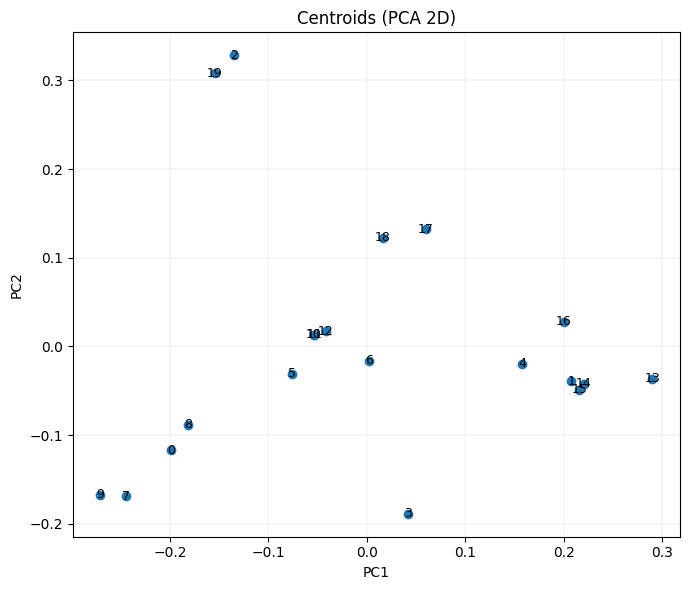

/home/ys0660/anaconda3/envs/ys0660/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:991: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


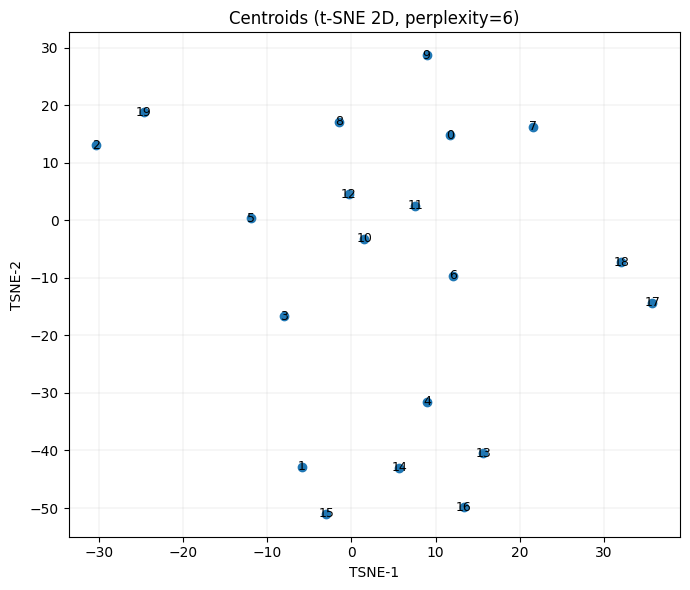

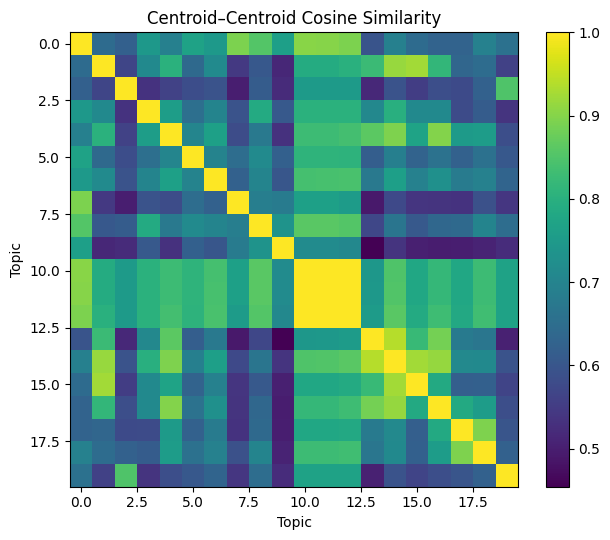

In [143]:
# =========================
# 2D 시각화: PCA (옵션: t-SNE)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# (A) soft_results.npz에서 centroid 로드
# - 이미 load_soft_results 함수가 있다면 그걸 써도 되고,
# - 없으면 아래 np.load 경로만 바꿔서 바로 로드해도 됨.
npz_path = "/home/ys0660/2507Sub/textclustering/0915/Topicker/data/20NG/text-embedding-3-small/soft_results.npz"

data = np.load(npz_path, allow_pickle=True)
# 관례적으로 보통 'C' 또는 'centroids' 키로 들어있음. 키 이름 확인:
print("NPZ keys:", list(data.keys()))

# 키 추정: 'C' 또는 'centroids' 또는 'C_loaded' 같은 이름일 수 있음
for key in ["C", "centroids", "C_loaded", "centroid", "centers"]:
    if key in data:
        C_loaded = data[key]
        break
else:
    raise KeyError("centroid 행렬(C_loaded)을 찾을 수 없습니다. NPZ keys를 확인하세요.")

print("C_loaded shape:", C_loaded.shape)  # (K, D)

# (B) 간단한 진단: 노름/분산/상관
norms = np.linalg.norm(C_loaded, axis=1)
print(f"[diag] centroid L2-norm -> min={norms.min():.4f}, max={norms.max():.4f}, mean={norms.mean():.4f}")

# (C) 차원 축소: PCA -> 2D
from sklearn.decomposition import PCA

# 평균 제거(권장)
C_centered = C_loaded - C_loaded.mean(axis=0, keepdims=True)

pca = PCA(n_components=2, random_state=42)
C_2d = pca.fit_transform(C_centered)

print(f"[PCA] explained variance ratio: {pca.explained_variance_ratio_} "
      f"(sum={pca.explained_variance_ratio_.sum():.3f})")

# (D) 2D 산점도 (토픽 라벨은 0 ~ K-1로 가정)
K = C_loaded.shape[0]
plt.figure(figsize=(7, 6))
plt.scatter(C_2d[:, 0], C_2d[:, 1])
for k in range(K):
    plt.text(C_2d[k, 0], C_2d[k, 1], str(k), fontsize=9, ha='center', va='center')
plt.title("Centroids (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

# =========================
# (옵션) t-SNE로도 확인
# =========================
# - K가 너무 크지 않다면 t-SNE도 유용. (K ~ 수백 이하면 OK)
# - t-SNE는 랜덤성/하이퍼파라미터(perplexity 등)에 민감하므로 여러 번 돌려보자.
try:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=min(30, max(5, K//3)), init="pca", learning_rate="auto", random_state=42)
    C_2d_tsne = tsne.fit_transform(C_centered)

    plt.figure(figsize=(7, 6))
    plt.scatter(C_2d_tsne[:, 0], C_2d_tsne[:, 1])
    for k in range(K):
        plt.text(C_2d_tsne[k, 0], C_2d_tsne[k, 1], str(k), fontsize=9, ha='center', va='center')
    plt.title(f"Centroids (t-SNE 2D, perplexity={tsne.perplexity})")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.grid(True, linewidth=0.3, alpha=0.5)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[warn] t-SNE 시각화 생략:", repr(e))

# =========================
# (옵션) 코사인 유사도 히트맵으로 구조 확인
# =========================
# - 센트로이드간 유사도가 모두 비슷하거나, 특정 축으로만 뭉쳐 있으면
#   학습/정규화 과정 문제 가능성 진단에 도움.
def l2_normalize(A, eps=1e-12):
    n = np.linalg.norm(A, axis=1, keepdims=True)
    n = np.clip(n, eps, None)
    return A / n

Cn = l2_normalize(C_loaded)
cos_sim = Cn @ Cn.T   # (K, K)

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cos_sim, aspect='auto')
plt.title("Centroid–Centroid Cosine Similarity")
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.colorbar()
plt.tight_layout()
plt.show()


3. 제발..

In [145]:
import os
from typing import List, Dict, Tuple, Union, Optional
import numpy as np
import pandas as pd
from tqdm import tqdm
from openai import OpenAI
import tiktoken

# =========================
# 공통 유틸
# =========================
MODEL = "text-embedding-3-small"
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
enc = tiktoken.encoding_for_model(MODEL)
MAX_TOKENS = 8192

def truncate_text(text: str, max_tokens: int = MAX_TOKENS) -> str:
    toks = enc.encode(text or "")
    if len(toks) > max_tokens:
        toks = toks[:max_tokens]
    return enc.decode(toks)

def embed_texts(texts: List[str], model: str = MODEL) -> np.ndarray:
    """문장 리스트를 임베딩 (N, D)"""
    embs = []
    for t in tqdm(texts, desc="Embedding texts"):
        t = truncate_text(t.strip())
        if not t:
            embs.append(np.zeros(1536, dtype=np.float32))
            continue
        r = client.embeddings.create(model=model, input=t)
        embs.append(np.asarray(r.data[0].embedding, dtype=np.float32))
    return np.vstack(embs)

def embed_words_average(words: List[str], weights: Optional[List[float]] = None, model: str = MODEL) -> np.ndarray:
    """단어별 임베딩 후 (가중)평균 -> (D,)"""
    if not words:
        return np.zeros(1536, dtype=np.float32)
    # 배치로 보내도 되지만 단어 수가 적으면 루프도 충분
    vecs = []
    ws = np.ones(len(words), dtype=np.float32) if weights is None else np.asarray(weights, dtype=np.float32)
    ws = ws / (ws.sum() + 1e-12)
    for w in words:
        w = truncate_text(str(w).strip())
        if not w:
            vecs.append(np.zeros(1536, dtype=np.float32))
            continue
        r = client.embeddings.create(model=model, input=w)
        vecs.append(np.asarray(r.data[0].embedding, dtype=np.float32))
    V = np.vstack(vecs)                    # (m, D)
    return (ws[:, None] * V).sum(axis=0)   # (D,)

def l2_normalize(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    n = np.linalg.norm(A, axis=1, keepdims=True)
    n = np.clip(n, eps, None)
    return A / n

# =========================
# 토픽 표현 만들기
# =========================
def build_topic_reprs(
    topics: List[List[str]],
    mode: str = "concat",          # "concat" | "avg" | "wavg"
    topn: int = 10,
    weights: Optional[List[List[float]]] = None,  # c-tf-idf 같은 가중치 (topic마다 topn 길이)
    model: str = MODEL
) -> np.ndarray:
    """
    반환: topic_reprs (K, D)
    - concat: 상위단어들을 "w1 w2 ... wN"로 이어 붙여 문장 임베딩
    - avg:    단어별 임베딩 평균
    - wavg:   단어별 임베딩 가중 평균(가중치는 weights 인자)
    """
    K = len(topics)
    if mode == "concat":
        texts = [" ".join(t[:topn]) for t in topics]
        T = embed_texts(texts, model=model)           # (K, D)
        return T

    reps = []
    for k in range(K):
        words = topics[k][:topn]
        if mode == "avg":
            v = embed_words_average(words, None, model=model)
        elif mode == "wavg":
            w = None if weights is None else weights[k][:len(words)]
            v = embed_words_average(words, w, model=model)
        else:
            raise ValueError("mode must be one of {'concat','avg','wavg'}")
        reps.append(v)
    return np.vstack(reps)

# =========================
# gpt_label vs topic_reprs 코사인 점수
# =========================
def score_gpt_labels_against_topics(
    gpt_labels: List[str],
    topic_reprs: np.ndarray
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    gpt_labels 임베딩 ↔ topic_reprs 코사인 유사도 점수
    반환:
      S: (N, K) 점수행렬
      top_idx: (N,) argmax topic
      top_val: (N,) 최고 점수
    """
    X = embed_texts(gpt_labels, model=MODEL)   # (N, D)
    Xn = l2_normalize(X)
    Cn = l2_normalize(topic_reprs)
    S = Xn @ Cn.T                               # (N, K), cosine similarity
    top_idx = np.argmax(S, axis=1)
    top_val = S[np.arange(S.shape[0]), top_idx]
    return S, top_idx, top_val

# =========================
# 사용 예시
# =========================
# topics: List[List[str]]  # c-TF-IDF 등으로 뽑은 상위단어들
# weights: Optional[List[List[float]]]  # (선택) 각 단어의 점수(가중치)
# df: DataFrame with 'gpt_topic_free'
def score_pipeline(df: pd.DataFrame, topics: List[List[str]], weights=None, mode="concat", topn=10):
    mask = df["gpt_topic_free"].notna() & (df["gpt_topic_free"].astype(str).str.strip() != "")
    idx = df.index[mask]
    gpt_texts = df.loc[idx, "gpt_topic_free"].astype(str).tolist()

    # 1) 토픽 표현 생성
    topic_reprs = build_topic_reprs(topics, mode=mode, topn=topn, weights=weights, model=MODEL)  # (K, D)

    # 2) 점수 계산
    S, top_idx, top_val = score_gpt_labels_against_topics(gpt_texts, topic_reprs)

    # 3) df에 점수 요약만 적재 (원하면 전체 S를 npz로 저장 권장)
    df.loc[idx, "gpt_free_top_topic_from_words"] = top_idx
    df.loc[idx, "gpt_free_top_score_from_words"] = top_val

    return S, topic_reprs

# 예: 실행
S, topic_reprs = score_pipeline(df, topics, weights=None, mode="concat", topn=10)
# 또는: S, topic_reprs = score_pipeline(df, topics, weights=ctfidf_weights, mode="wavg", topn=10)


Embedding texts: 100%|██████████| 7269/7269 [39:25<00:00,  3.07it/s]  


In [146]:
import numpy as np

# S: (N, K) 유사도 행렬
top3_idx = np.argsort(-S, axis=1)[:, :3]  # 상위 3개 토픽 인덱스
top3_val = np.take_along_axis(S, top3_idx, axis=1)

for i, label in enumerate(df.loc[df["gpt_topic_free"].notna(), "gpt_topic_free"].tolist()[:5]):
    print(f"\n[GPT Label] {label}")
    for rank, (tid, val) in enumerate(zip(top3_idx[i], top3_val[i]), start=1):
        print(f"  Top-{rank}: Topic {tid} (score={val:.3f})")



[GPT Label] Visual Perception Experiments
  Top-1: Topic 1 (score=0.253)
  Top-2: Topic 10 (score=0.167)
  Top-3: Topic 5 (score=0.152)

[GPT Label] Tech Support Contacts
  Top-1: Topic 2 (score=0.279)
  Top-2: Topic 4 (score=0.271)
  Top-3: Topic 3 (score=0.235)

[GPT Label] Bruins Goalie Performance
  Top-1: Topic 10 (score=0.434)
  Top-2: Topic 9 (score=0.276)
  Top-3: Topic 8 (score=0.152)

[GPT Label] Ordo Templi Orientis
  Top-1: Topic 15 (score=0.278)
  Top-2: Topic 2 (score=0.185)
  Top-3: Topic 14 (score=0.180)

[GPT Label] Aviation Learning Experience
  Top-1: Topic 14 (score=0.216)
  Top-2: Topic 8 (score=0.198)
  Top-3: Topic 9 (score=0.181)


In [149]:
# 우선 gpt_free_top_topic_from_words가 DataFrame에 있어야 합니다.
# (앞서 score_pipeline 실행 시 자동으로 들어가게 되어 있음)

# 새로운 칼럼 gpt_v3_label 생성
df["gpt_v3_label"] = df["gpt_free_top_topic_from_words"]

# 값이 비어있는 경우 cluster_label 값으로 대체
mask_empty = df["gpt_v3_label"].isna()
df.loc[mask_empty, "gpt_v3_label"] = df.loc[mask_empty, "cluster_label"]

# int로 강제 캐스팅 (cluster_label이 int일 때)
df["gpt_v3_label"] = df["gpt_v3_label"].astype(int)

print(df[["gpt_topic_free", "gpt_free_top_topic_from_words", "cluster_label", "gpt_v3_label"]].head(10))


                  gpt_topic_free  gpt_free_top_topic_from_words  \
0                           None                            NaN   
1                           None                            NaN   
2                           None                            NaN   
3                           None                            NaN   
4                           None                            NaN   
5  Visual Perception Experiments                            1.0   
6          Tech Support Contacts                            2.0   
7                           None                            NaN   
8      Bruins Goalie Performance                           10.0   
9                           None                            NaN   

   cluster_label  gpt_v3_label  
0             10            10  
1              3             3  
2             17            17  
3              3             3  
4              3             3  
5             12             1  
6              4             2 

In [151]:
labels_true_eval = df["label_id"].to_numpy()
labels_pred_eval = df["gpt_v3_label"].astype(int).to_numpy()

# 3) 지표 계산
res = evaluate_topics_and_clusters(
    labels_true=labels_true_eval,
    labels_pred_aligned=labels_pred_eval,
    topics=topics,                                  # 토픽 지표 포함
    texts=df["cleaned_text"].tolist(),
    topn=10
)
print(res)

{'p1_macro_f1': 0.5656416992042319, 'ari': 0.41651494722617105, 'nmi': 0.5408770317755537, 'topic_coherence_cv': 0.7217309169026398, 'topic_diversity': 0.88}


In [148]:
df.to_csv('/home/ys0660/2507Sub/textclustering/0915/Topicker/tester.csv')

In [153]:
df.tail()

,text,label_id,label_name,cleaned_text,cluster_label,gpt_topic_id,gpt_label,gpt_topic_free,gpt_free_label,gpt_free_top_topic_from_words,gpt_free_top_score_from_words,gpt_v3_label
18230,dn from david nye dn a neurology dn consultati...,13,sci.med,neurology consultation cheap scan neurologist ...,13,<NA>,13,None,13,NaN,NaN,13
18231,in article engineer by day asleep by night wri...,12,sci.electronics,engineer day asleep night isolated ground rece...,12,<NA>,12,None,12,NaN,NaN,12
18232,i just installed a dx2 66 cpu in a clone mothe...,3,comp.sys.ibm.pc.hardware,cpu clone motherboard cpu cooler chip hour wei...,3,4,4,CPU Cooler Installation,5,3.0,0.26875,3
18233,in article edward bolson writes wouldn t this ...,1,comp.graphics,wouldn hyper sphere space point specifie spher...,14,<NA>,14,None,14,NaN,NaN,14
18234,after a tip from gary crum i got on the phone ...,7,rec.autos,tip gary crum pontiac pontaic customer service...,7,<NA>,7,None,7,NaN,NaN,7


총 개수(일치): 2451
전체 개수(비어있지 않음): 7269
일치율: 33.72%

[일치하는 경우 score 통계]
count    2451.000000
mean        0.320462
std         0.087007
min         0.128031
25%         0.256111
50%         0.309631
75%         0.377575
max         0.699626
Name: gpt_free_top_score_from_words, dtype: float64

[불일치하는 경우 score 통계]
count    4818.000000
mean        0.285606
std         0.082848
min         0.112072
25%         0.224480
50%         0.273427
75%         0.333977
max         0.628478
Name: gpt_free_top_score_from_words, dtype: float64


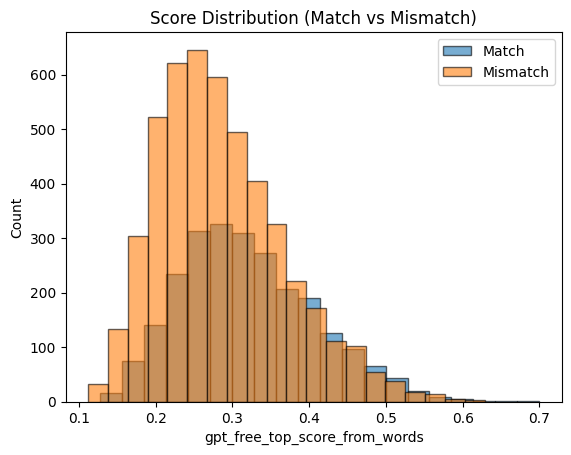

In [162]:
import matplotlib.pyplot as plt

# (1) gpt_free_top_score_from_words가 비어있지 않은 행만 필터링
subset = df[df["gpt_free_top_score_from_words"].notna()].copy()

# (2) gpt_free_top_topic_from_words와 cluster_label 일치 여부 확인
subset["free_match"] = subset["gpt_free_top_topic_from_words"] == subset["cluster_label"]

# (3) 개수 세기 (총 개수 = 일치하는 경우의 개수)
total_count = subset["free_match"].sum()
all_count = len(subset)

print(f"총 개수(일치): {total_count}")
print(f"전체 개수(비어있지 않음): {all_count}")
print(f"일치율: {total_count / all_count:.2%}")

# (4) 점수 분포 확인
scores_match    = subset.loc[subset["free_match"], "gpt_free_top_score_from_words"]
scores_mismatch = subset.loc[~subset["free_match"], "gpt_free_top_score_from_words"]

# 통계치 출력
print("\n[일치하는 경우 score 통계]")
print(scores_match.describe())

print("\n[불일치하는 경우 score 통계]")
print(scores_mismatch.describe())

# (5) 히스토그램 비교
plt.hist(scores_match, bins=20, alpha=0.6, label="Match", edgecolor="black")
plt.hist(scores_mismatch, bins=20, alpha=0.6, label="Mismatch", edgecolor="black")
plt.xlabel("gpt_free_top_score_from_words")
plt.ylabel("Count")
plt.title("Score Distribution (Match vs Mismatch)")
plt.legend()
plt.show()


In [158]:
same_count = len(subset)
total_count = len(df)
ratio = same_count / total_count

print(f"전체 개수: {total_count}")
print(f"같은 것의 개수: {same_count}")
print(f"일치율: {ratio:.2%}")

전체 개수: 18235
같은 것의 개수: 13417
일치율: 73.58%
